### Why detect outlier
1. *method 1 :visual detection using box plot*
   * a box plot shows quickly:
     1. minimun value
     2. Q1
     3. meadian
     4. Q3
     5. maxmium value
     6. outlier
2. *method 2 :IQR method*
   * IQR =interqurtile range
   * formula :IQR=Q3-Q1
   * step 1:calculate iqr
   * step 2:calculate limits-lower limits and -upper limits
   * step 3:detect outlier
3. *method 3 z-score method*
   * measure how many standard deviation a value is from the mean.
   * step 1:calculate z-score
   * step 3:detect outlier

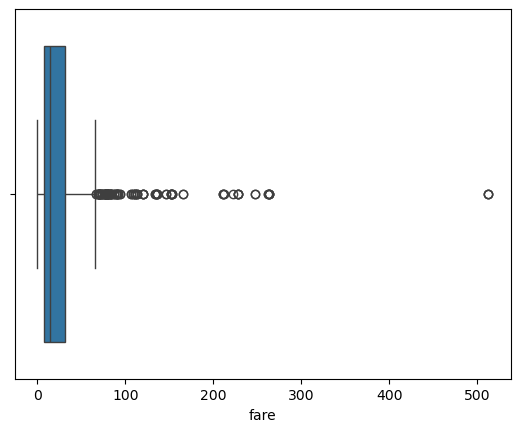

IQR Outlier: <built-in function len>      survived  pclass     sex   age  sibsp  parch      fare embarked  class  \
1           1       1  female  38.0      1      0   71.2833        C  First   
27          0       1    male  19.0      3      2  263.0000        S  First   
31          1       1  female   NaN      1      0  146.5208        C  First   
34          0       1    male  28.0      1      0   82.1708        C  First   
52          1       1  female  49.0      1      0   76.7292        C  First   
..        ...     ...     ...   ...    ...    ...       ...      ...    ...   
846         0       3    male   NaN      8      2   69.5500        S  Third   
849         1       1  female   NaN      1      0   89.1042        C  First   
856         1       1  female  45.0      1      1  164.8667        S  First   
863         0       3  female   NaN      8      2   69.5500        S  Third   
879         1       1  female  56.0      0      1   83.1583        C  First   

       who  ad

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

#load titanic dataset
df=sns.load_dataset('titanic')
sns.boxplot(x=df['fare'])

#IQR method
plt.show()
Q1=df['fare'].quantile(0.25)
Q3=df['fare'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR 
outlier_iqr=df[
    (df['fare']<lower)|
    (df['fare']>upper)]
print("IQR Outlier:", len,(outlier_iqr))

#zscore method
df['fare_zscore']=zscore(df['fare'])
outliers_z=df[
    abs(df['fare_zscore'])>3]
print("Z-score outlier:",len(outliers_z))

### Why EDA is important 
1. understand the structure of the dataset
2. identify missing values
3. detect outlier
4. understand feature distributions
5. find realtionship between variables check data quality issuse
6. check data quality issuse
7. prepare data fro machine learning
### types of eda
*univariate analysis*
* analysing one variable at a time.

*numerical feature*
* mean,madian,mode,standard deviation , variance,histogram,box,plot

*categorical features*
* values counts, frequency distribution, bar chart

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=sns.load_dataset("tips")
print(df.head())
print(df.info())
print(df.columns)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


In [5]:
print(df['total_bill'].describe ())

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


### 2. histogram
* a histogram shows the distribution of a numerical feature.
* id divides data into intervels(bins)and shows how many observations fall into each interval. 

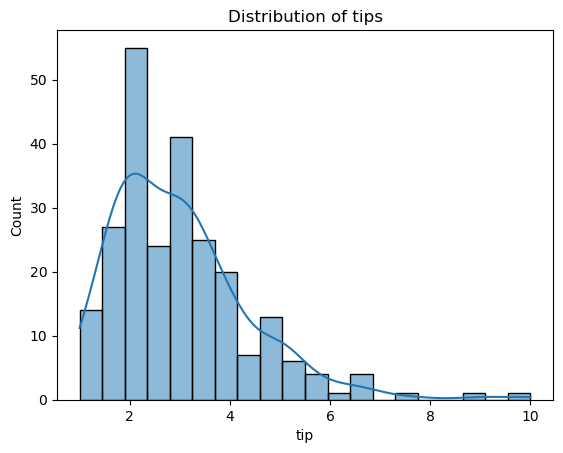

In [9]:
sns.histplot(df['tip'],bins=20,kde=True)
plt.title("Distribution of tips")
plt.show()

In [10]:
print(df['day'].value_counts())

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


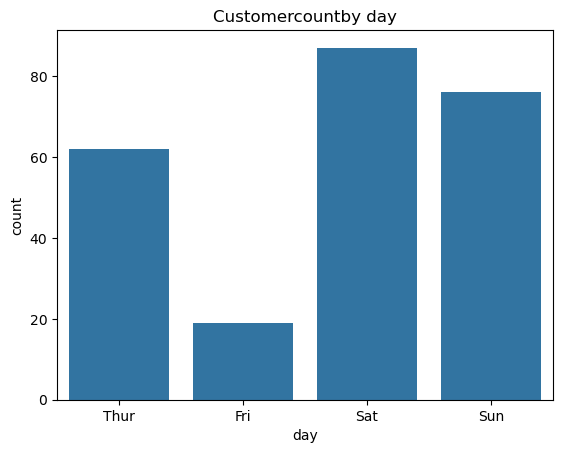

In [11]:
#count plot
sns.countplot(x='day',data=df)
plt.title("Customercountby day")
plt.show()

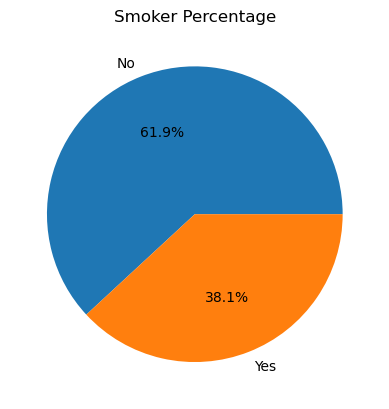

In [13]:
#pie chart
df['smoker'].value_counts().plot(
    kind='pie',autopct='%1.1f%%')
plt.title("Smoker Percentage")
plt.ylabel("")
plt.show()

In [17]:
Q1=df['total_bill'].quantile(0.25)
Q3=df['total_bill'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outlier=df[(df['total_bill']<lower)|
            (df['total_bill']>upper)]
print("Outliers:",len(outlier))

Outliers: 9


### Bivarite analysis
* bivarites analysis means analysing two variable together to understand the realtionship between them.
* bi=two
* variate=varibles

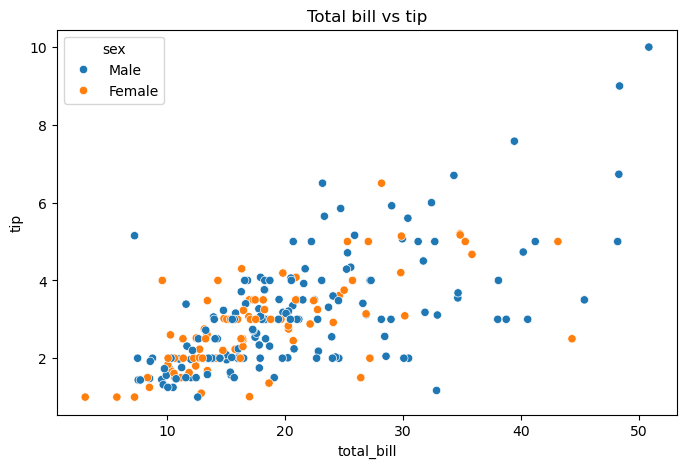

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='total_bill',
    y='tip',
    hue='sex',
    data=df)
plt.title("Total bill vs tip")
plt.show()

#### correlation
pearson correlation

In [24]:
corr=df['total_bill'].corr(df['tip'])
print(corr)

0.6757341092113641


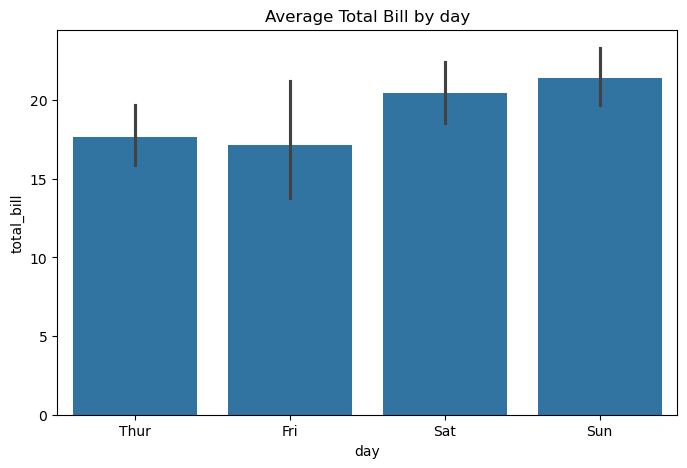

In [26]:
#bar chart
plt.figure(figsize=(8,5))
sns.barplot(
    x='day',
    y='total_bill',
    data=df)
plt.title("Average Total Bill by day")
plt.show()

In [28]:
#grouped statitics
#meanbill by day
print(df.groupby('day',observed=False)['total_bill'].mean())
#multiple statistics
print(df.groupby('day',observed=False)['total_bill'].agg(['mean','min','max']))

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64
           mean   min    max
day                         
Thur  17.682742  7.51  43.11
Fri   17.151579  5.75  40.17
Sat   20.441379  3.07  50.81
Sun   21.410000  7.25  48.17


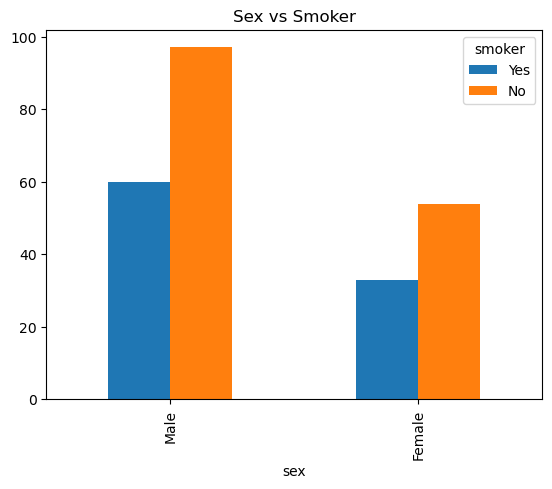

In [29]:
#bar chart
pd.crosstab(
    df['sex'],
    df['smoker']).plot(kind='bar')
plt.title("Sex vs Smoker")
plt.show()

#### Multivariate analysis
* Mulitvarite analaysis means analyzing three or move variables simultaneously to understand complex realtionships and patterns in data.

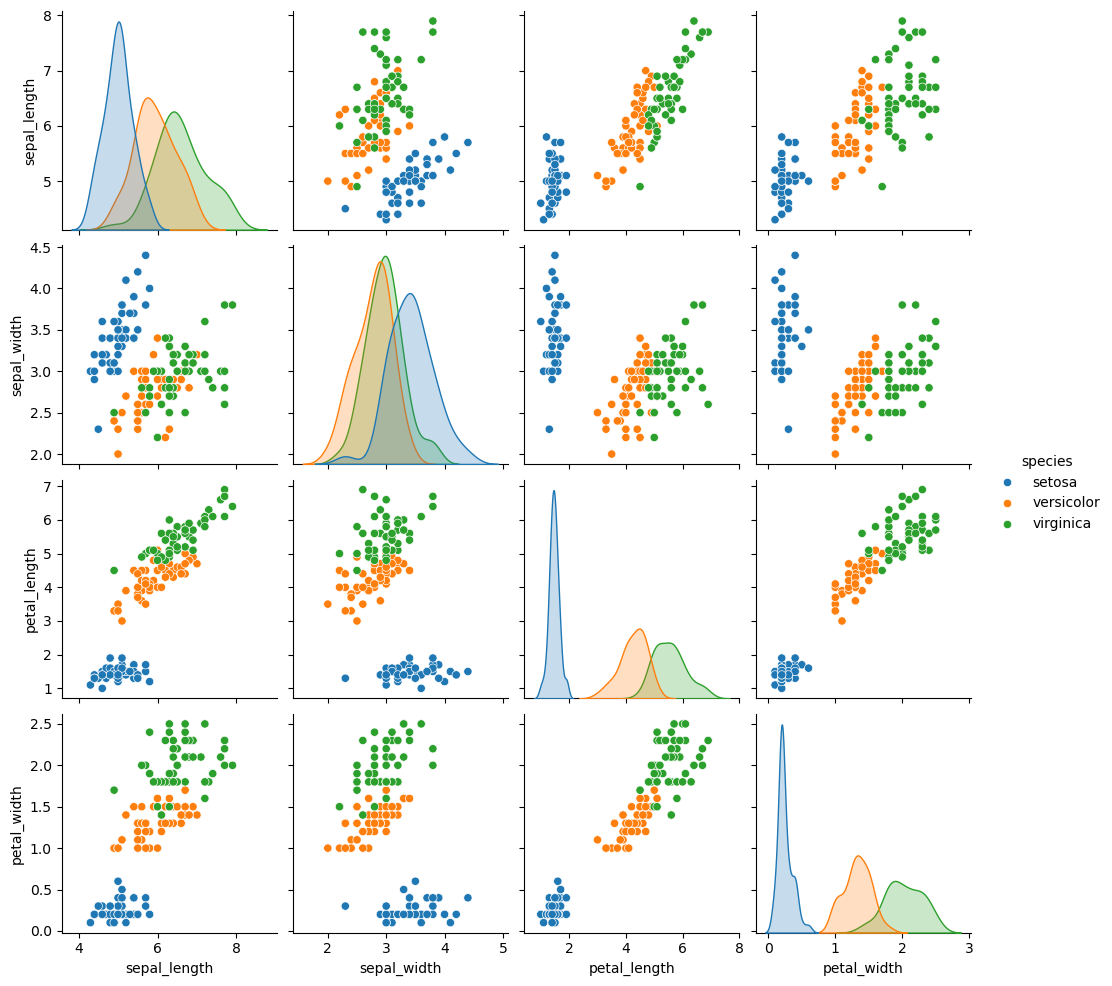

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
df=sns.load_dataset("iris")
sns.pairplot(df,hue='species')
plt.show()

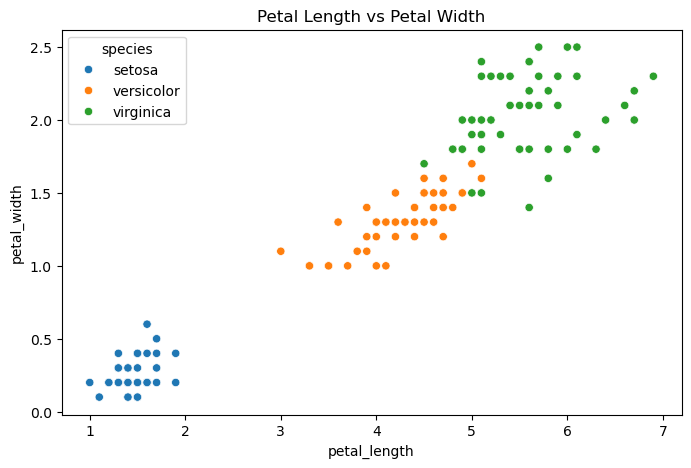

In [40]:
plt.figure(figsize=(8, 5))
# Fixed the spelling of 'petal_length'
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=df)
plt.title("Petal Length vs Petal Width")
plt.show()

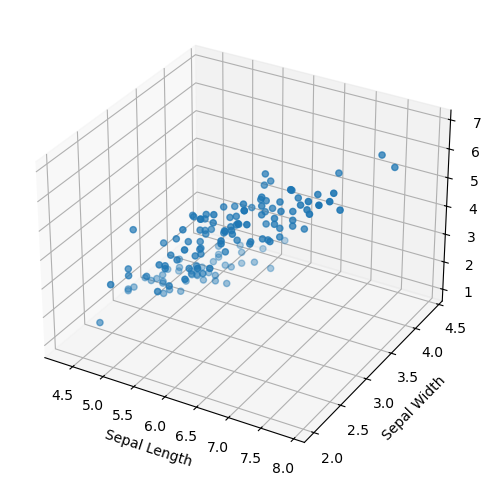

In [48]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['sepal_length'], df['sepal_width'], df['petal_length'])

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')

plt.show()

#### correlation analysis
what is correlation?
* correlation measures the strength and direction of realtion

In [49]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
df=sns.load_dataset('iris')

In [50]:
corr_matrix=df.corr(numeric_only=True)
print(corr_matrix)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


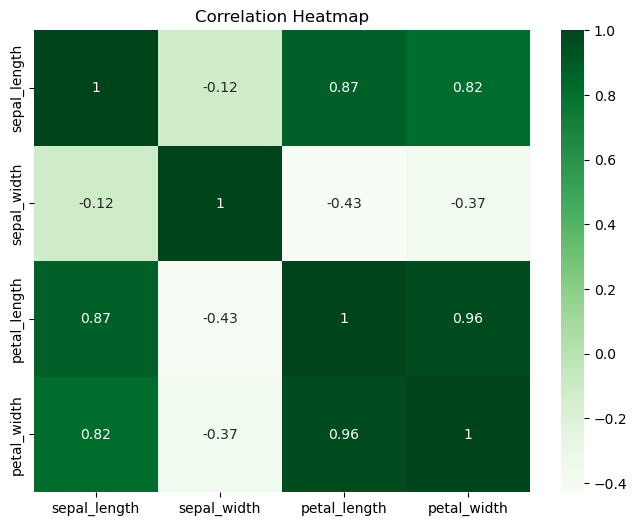

In [53]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='Greens')
plt.title("Correlation Heatmap")
plt.show()

### VIF(variance inflation factor) for multicollinearity detection

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
x=df.drop("species",axis=1)
vif=pd.DataFrame()
vif["Features"]=x.columns
vif["VIF"]=[
    variance_inflation_factor(x.values,i)
    for i in range(x.shape[1])]
print(vif)

       Features         VIF
0  sepal_length  262.969348
1   sepal_width   96.353292
2  petal_length  172.960962
3   petal_width   55.502060


In [56]:
# remove a high vif feature
# suppose we remove sepal_length:
x_new = x.drop("sepal_length", axis=1)

vif_after = pd.DataFrame()
vif_after["Feature"] = x_new.columns

# Fixed the spelling of variance_inflation_factor and changed X_new to x_new
vif_after["VIF"] = [variance_inflation_factor(x_new.values, i) for i in range(x_new.shape[1])]

print(vif_after)

        Feature        VIF
0   sepal_width   5.856965
1  petal_length  62.071308
2   petal_width  43.292574
